# Exploratory Data Analysis — Online Retail II

Analyses revenue trends, month-over-month growth, and geographic distribution.

**Dataset:** [Online Retail II](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci) — place the file at `data/online_retail_II.xlsx`

## 1. Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel("data/online_retail_II.xlsx")
print(df.shape)

(525461, 8)


## 2. Basic Exploration

In [2]:
# Extract month from invoice date for time-series analysis
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['Revenue'] = df['Quantity'] * df['Price']

print(df.describe())
print("\nMissing values:")
print(df.isna().sum())

            Quantity                    InvoiceDate          Price  \
count  525461.000000                         525461  525461.000000   
mean       10.337667  2010-06-28 11:37:36.845017856       4.688834   
min     -9600.000000            2009-12-01 07:45:00  -53594.360000   
25%         1.000000            2010-03-21 12:20:00       1.250000   
50%         3.000000            2010-07-06 09:51:00       2.100000   
75%        10.000000            2010-10-15 12:45:00       4.210000   
max     19152.000000            2010-12-09 20:01:00   25111.090000   
std       107.424110                            NaN     146.126914   

         Customer ID        Revenue  
count  417534.000000  525461.000000  
mean    15360.645478      18.154506  
min     12346.000000  -53594.360000  
25%     13983.000000       3.750000  
50%     15311.000000       9.950000  
75%     16799.000000      17.700000  
max     18287.000000   25111.090000  
std      1680.811316     160.333083  

Missing values:
Invoice   

## 3. Monthly Revenue & MoM Growth

In [3]:
monthly_revenue = df.groupby('Month').agg({
    'Invoice': 'nunique',
    'Customer ID': 'nunique',
    'Revenue': 'sum'
}).reset_index()

# Month-over-month growth rate
monthly_revenue['MOM_growth'] = monthly_revenue['Revenue'].pct_change() * 100
monthly_revenue

,Month,Invoice,Customer ID,Revenue,MOM_growth
0,2009-12,2330,1045,799847.110,NaN
1,2010-01,1633,786,624032.892,-21.980978
2,2010-02,1969,807,533091.426,-14.573185
3,2010-03,2367,1111,765848.761,43.661804
4,2010-04,1892,998,590580.432,-22.885501
5,2010-05,2418,1062,615322.830,4.189505
6,2010-06,2216,1095,679786.610,10.476416
7,2010-07,2017,988,575236.360,-15.379863
8,2010-08,1877,964,656776.340,14.175039
9,2010-09,2375,1202,853650.431,29.975820


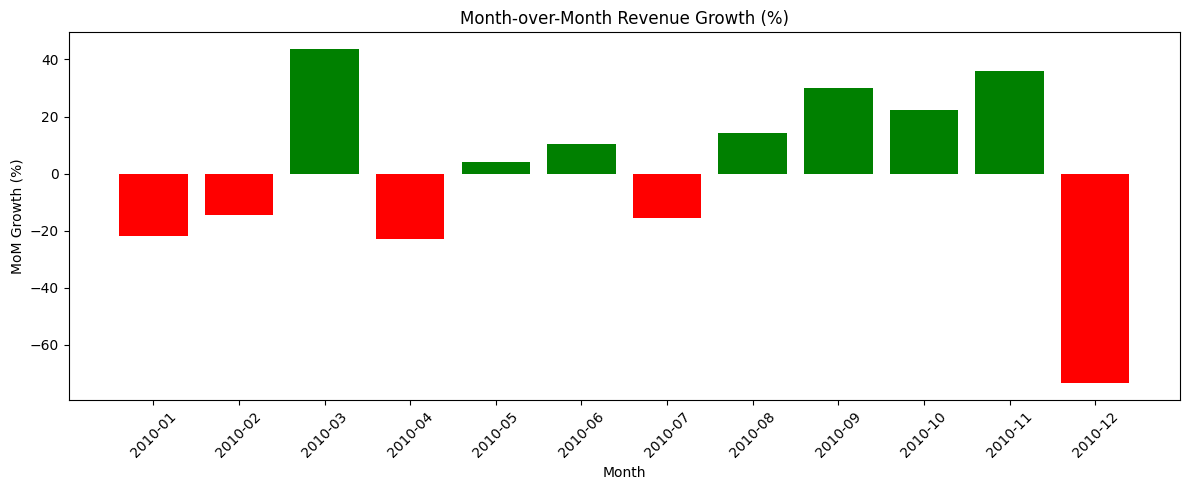

In [4]:
# Green bars = growth, red bars = decline
plt.figure(figsize=(12, 5))
plt.bar(
    monthly_revenue['Month'].astype(str),
    monthly_revenue['MOM_growth'],
    color=np.where(monthly_revenue['MOM_growth'] <= 0, 'red', 'green')
)
plt.title('Month-over-Month Revenue Growth (%)')
plt.xlabel('Month')
plt.ylabel('MoM Growth (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Top 10 Countries by Revenue

In [5]:
country_revenue = df.groupby('Country').agg({
    'Customer ID': 'nunique',
    'Revenue': 'sum'
}).sort_values('Revenue', ascending=False).reset_index()

top_10 = country_revenue[:10]
top_10['Revenue_share'] = top_10['Revenue'] / country_revenue['Revenue'].sum() * 100
top_10

/var/folders/m7/066qnkwx61lf26m2498cp28r0000gn/T/ipykernel_20060/1825951659.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10['Revenue_share'] = top_10['Revenue'] / country_revenue['Revenue'].sum() * 100


,Country,Customer ID,Revenue,Revenue_share
0,United Kingdom,4035,8194777.533,85.903776
1,EIRE,5,352242.730,3.692471
2,Netherlands,23,263863.410,2.766013
3,Germany,68,196290.351,2.057662
4,France,47,130769.900,1.370828
5,Sweden,16,51213.510,0.536858
6,Denmark,9,46972.950,0.492406
7,Switzerland,14,43343.410,0.454358
8,Spain,25,37084.900,0.388752
9,Australia,15,30051.800,0.315025


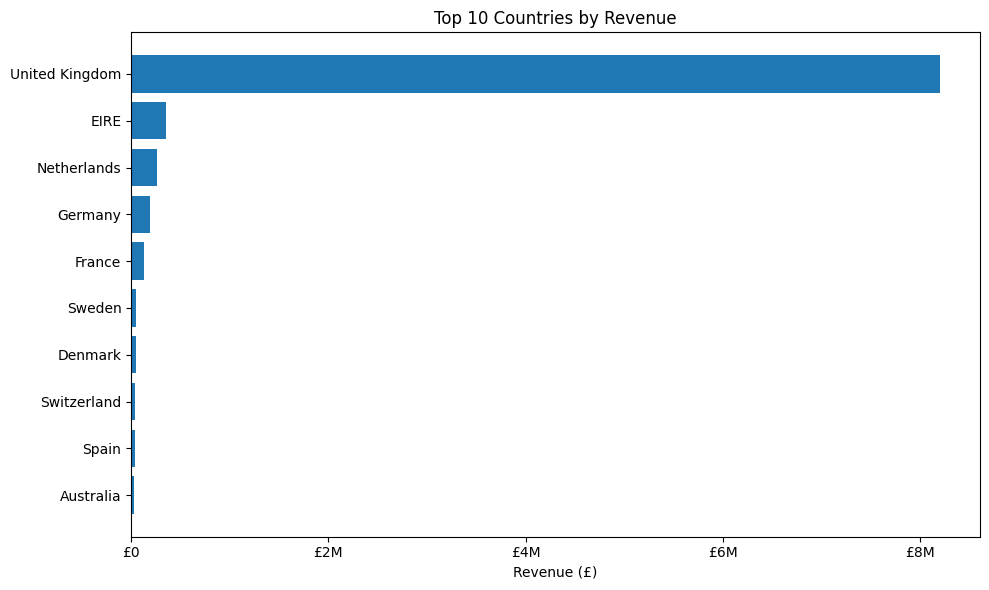

In [6]:
plt.figure(figsize=(10, 6))
plt.barh(top_10['Country'], top_10['Revenue'])
plt.gca().invert_yaxis()
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.xticks(ticks=[0, 2e6, 4e6, 6e6, 8e6],
           labels=['£0', '£2M', '£4M', '£6M', '£8M'])
plt.tight_layout()
plt.show()

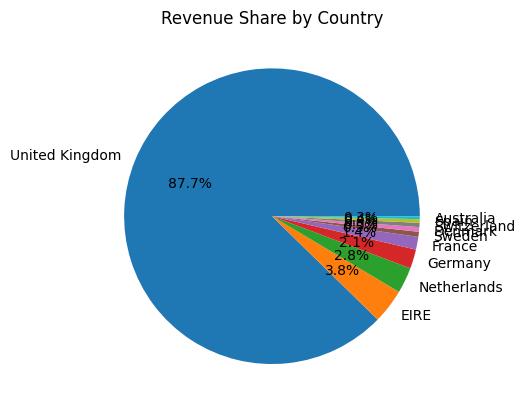

In [7]:
# Revenue share pie chart (top 10 countries)
plt.pie(top_10['Revenue_share'], labels=top_10['Country'], autopct='%1.1f%%')
plt.title('Revenue Share by Country')
plt.show()

## 5. Monthly Revenue by Country

In [8]:
country_monthly = df.groupby(['Month', 'Country']).agg({
    'Invoice': 'nunique',
    'Quantity': 'sum',
    'Customer ID': 'nunique',
    'Revenue': 'sum'
}).reset_index()

# Sort so pct_change() is applied correctly within each country
country_monthly = country_monthly.sort_values(['Country', 'Month'])
country_monthly['MOM_growth'] = country_monthly.groupby('Country')['Revenue'].pct_change() * 100
country_monthly

,Month,Country,Invoice,Quantity,Customer ID,Revenue,MOM_growth
0,2009-12,Australia,5,53,3,50.25,NaN
43,2010-02,Australia,3,624,3,1029.66,1949.074627
62,2010-03,Australia,2,191,2,429.39,-58.297885
85,2010-04,Australia,2,560,2,630.95,46.941009
108,2010-05,Australia,8,665,4,1312.70,108.051351
...,...,...,...,...,...,...,...
107,2010-04,Unspecified,1,153,1,252.52,-74.706265
172,2010-07,Unspecified,3,1275,1,1189.94,371.226042
223,2010-09,Unspecified,3,1244,2,1967.95,65.382288
279,2010-11,Unspecified,5,363,1,528.77,-73.130923
